# Housing Price Prediction

## Goal: Predict House Price in Californian Districts

This is supervised learning task because the model trained with labeled data. This is Univariate Regression problem because we try to predict single value. This project use RMSE as a performance meassure. RMSE is more sensitive to outlier than MAE, so it is good if the outlier is very rare.

In [1]:
# Set the base path for local development
BASE_PATH = "."

## 1. Download Data

Step:
1. Download data from github
2. Quick look at the data
3. Create test set (use StratifiedSampling)  

Things to note before create test set:  
a. Create a test set early and keep it untouched    
b. Use random sampling with reproducible seeds  
c. Stratified sampling for representative splits  
d. Use stable hash-based splitting if data keep changing  

In this project, I use Stratified Sampling with income category because it is important attribute and must be representative. I also dont use hash-based splitting because the data is static.

### 1.1 - Download data from github

In [2]:
from pathlib import Path
import urllib.request
import tarfile
import pandas as pd

def load_data():
    filepath = Path(f"{BASE_PATH}/data/housing.tgz")  # where to store the data file
    if not filepath.is_file():  # check if the file already exists
        Path(f"{BASE_PATH}/data").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, filepath)
    with tarfile.open(filepath) as current_file:
        current_file.extractall(f"{BASE_PATH}/data")
    return pd.read_csv(f"{BASE_PATH}/data/housing/housing.csv")

housing_data = load_data()

/tmp/ipykernel_8762/4079326860.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  current_file.extractall(f"{BASE_PATH}/data")


### 1.2 - Quick look at the data

In [3]:
# Display the first 5 rows of the dataset
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Display information about the dataset
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# We can see that the "ocean_proximity" column type 'object', indicating it contains categorical data
# Check the unique values in the "ocean_proximity" column
housing_data["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [6]:
# Display statistical summary of the dataset (count, mean, std, min, 25%, 50%, 75%, max)
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


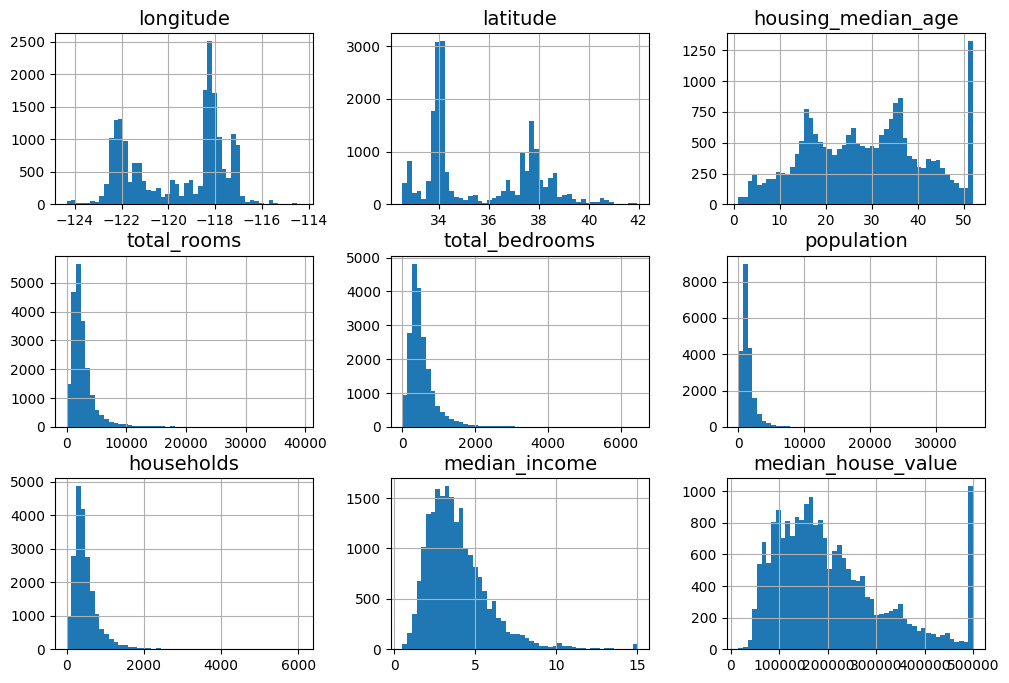

In [7]:
import matplotlib.pyplot as plt

# Set the default figure size and font sizes for better readability
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing_data.hist(bins=50, figsize=(12, 8))
plt.show()

### 1.3 - Create test set (use StratifiedSampling)

In [8]:
# Create new column for income categorys based on median_income
import numpy as np

housing_data["income_category"] = pd.cut(housing_data["median_income"],
                                         bins=[0., 1.5, 3.0, 4.5, 6, np.inf],
                                         labels=[1, 2, 3, 4, 5])

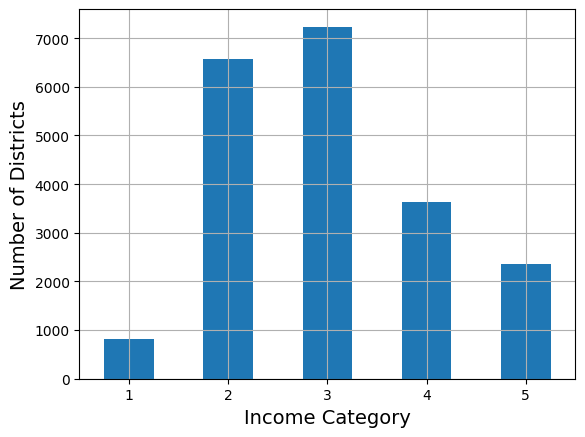

In [9]:
# Display histogram of income categories
housing_data["income_category"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
plt.show()

In [10]:
# Get a single stratified train/test split based on income category
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    housing_data, test_size=0.2, stratify=housing_data["income_category"], random_state=42)

In [11]:
# Remove income_category columns
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_category", axis=1, inplace=True)


## 2. Explore and Visualize the Data to Gain Insight

Step:
1. Visualizing geographical data  
Insight: Housing price are related to the location and population density (close to ocean and higher population tend to have higher prices)
2. Looking for correlations  
Insight: Median income is the most promising attribute to predict housing median value
3. Experiment with attribute combinations
Insight: We can combine some attributes to make it more useful (room_per_household, bedroom_per_room, population_per_household)

In [12]:
# Use copy() to avoid modifying the original data
strat_train_set_copy = strat_train_set.copy()

### 2.1 - Visualizing geographical data

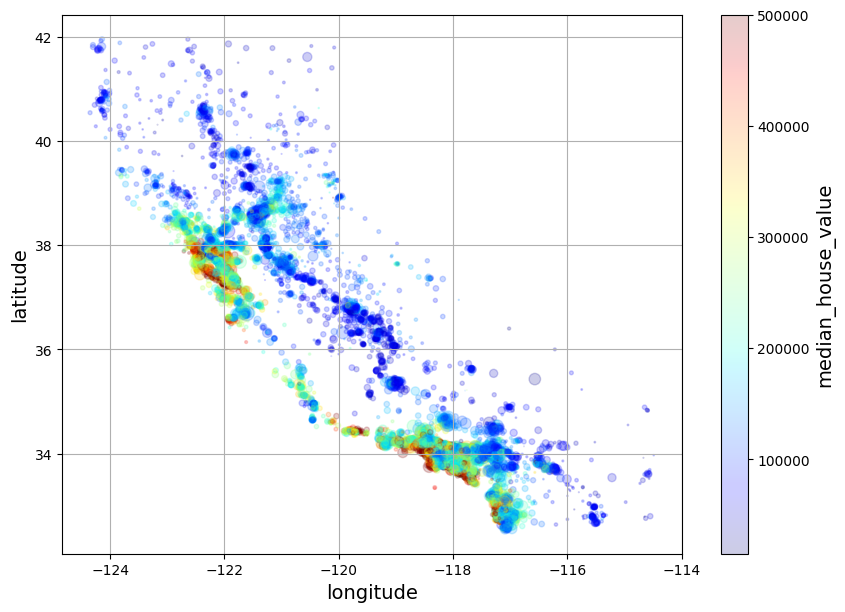

In [13]:
# Plot the geographical data points
strat_train_set_copy.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2,  # Transparency represents population density
    s=strat_train_set_copy["population"] / 100,  # Size (s) of each circle represents the district's population
    c="median_house_value",  # Color (c) represents the price (blue: low, red: high)
    cmap="jet",
    colorbar=True,
    grid=True,
    figsize=(10,7))

plt.show()

### 2.2 - Look for correlations

In [14]:
# Compute the correlation between each pair of attributes
correlation_matrix = strat_train_set_copy.corr(numeric_only=True)
correlation_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


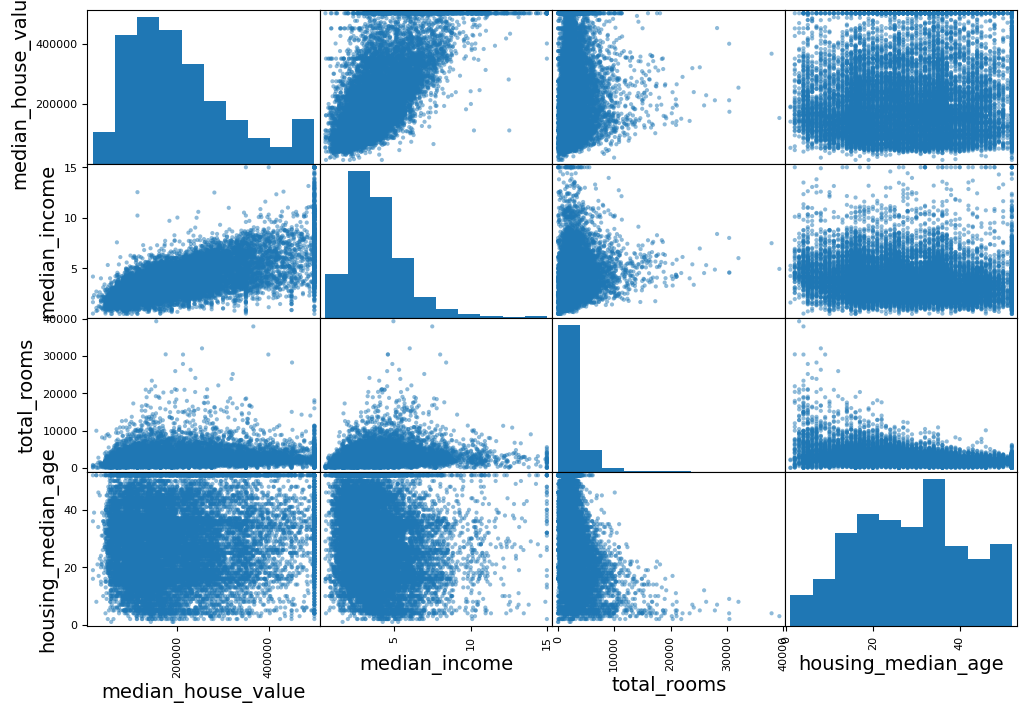

In [15]:
# Plot some promising attributes against the median house value
from pandas.plotting import scatter_matrix

promising_attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(strat_train_set_copy[promising_attributes], figsize=(12, 8))
plt.show()

# We can see that "median_income" is the most promising attribute to predict "median_house_value" (upward trend)

<Axes: xlabel='median_income', ylabel='median_house_value'>

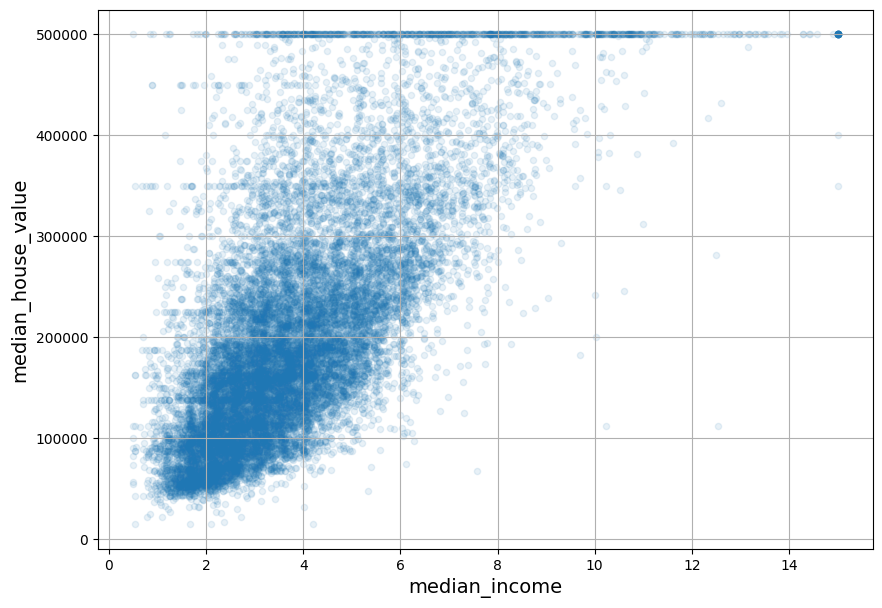

In [16]:
# Plot the most promising attribute against the median house value
strat_train_set_copy.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1,
    grid=True,
    figsize=(10,7))

# Insights:
# - There is a clear upward trend, indicating a positive correlation between median income and house value.
# - There is a horizontal line at 500,000, which is likely due to a cap on the maximum house value in the dataset.
# - There are also some horizontal lines at other values (450.000 and 350.000), indicating possible data quality issues.

### 2.3 - Experiment with attribute combinations

In [17]:
# Try a few attribute combinations
strat_train_set_copy["room_per_household"] = strat_train_set_copy["total_rooms"] / strat_train_set_copy["households"]
strat_train_set_copy["bedroom_per_room"] = strat_train_set_copy["total_bedrooms"] / strat_train_set_copy["total_rooms"]
strat_train_set_copy["population_per_household"] = strat_train_set_copy["population"] / strat_train_set_copy["households"]

strat_train_set_copy[["room_per_household", "bedroom_per_room", "population_per_household"]].describe()

,room_per_household,bedroom_per_room,population_per_household
count,16512.000000,16344.000000,16512.000000
mean,5.441010,0.212796,2.995974
std,2.574143,0.057417,4.457373
min,0.888889,0.100000,0.692308
25%,4.443636,0.175257,2.433426
50%,5.235573,0.203106,2.822316
75%,6.053843,0.239421,3.286385
max,141.909091,1.000000,502.461538


In [18]:
# Look at the correlation matrix
correlation_matrix = strat_train_set_copy.corr(numeric_only=True)
correlation_matrix["median_house_value"].sort_values(ascending=False)

# Insights:
# - "room_per_household" has a fairly strong positive correlation with "median_house_value"
# (higher rooms per household means more room in the house -> higher house value)
# - "bedroom_per_room" has a moderate negative correlation with "median_house_value"
# (higher bedrooms per rooms means smaller house -> lower house value)

,median_house_value
median_house_value,1.000000
median_income,0.688380
room_per_household,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
population_per_household,-0.038224
longitude,-0.050859


## 3. Prepare the Data for Machine Learning

Step:
1. Set the missing value with SimpleImputer
2. Handling text and categorical attributes with OneHotEncoder
3. Feature scaling and transformation with Standarization
4. Handle population with FunctionTransformer
5. Handle latitude and longtitude with CustomTransformer (use KMeans)

In [19]:
# Separate the predictors and the labels
strat_train_set_copy = strat_train_set.drop("median_house_value", axis=1)
strat_train_set_copy_labels = strat_train_set["median_house_value"].copy()

### 3.1 - Set the missing value (SimpleImputer)

In [20]:
# Total bedrooms has some missing values, we have 3 different options to handle them:
# 1. Get rid of the corresponding districts (rows)
# 2. Get rid of the whole attribute (column)
# 3. Set the missing values to some value (zero, mean, median, etc.)

print("Before imputation:")
print(strat_train_set_copy.isnull().sum())

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

# Select only the numerical attributes (median can only be computed on numerical attributes)
strat_train_set_copy_num = strat_train_set_copy.select_dtypes(include=[np.number])

# Fit the imputer instance to the training data and transform the training data
imputer.fit(strat_train_set_copy_num)
X = imputer.transform(strat_train_set_copy_num)

# The result is a NumPy array, convert it back to a DataFrame
strat_train_set_copy_transformed = pd.DataFrame(X, columns=strat_train_set_copy_num.columns, index=strat_train_set_copy_num.index)

# Check that there are no more missing values
print("\nAfter imputation:")
print(strat_train_set_copy_transformed.isnull().sum())

Before imputation:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        168
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

After imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64


### 3.2 - Handling text and categorical attributes (OneHotEncoder)

In [21]:
# This is categorical attribute
strat_train_set_copy_category = strat_train_set_copy[["ocean_proximity"]]
strat_train_set_copy_category.value_counts()

,count
ocean_proximity,
<1H OCEAN,7274
INLAND,5301
NEAR OCEAN,2089
NEAR BAY,1846
ISLAND,2


In [22]:
# We can use ordinal encoding, but it is not ideal because there is no natural order between the categories
# So we will use one-hot encoding to fix this issue
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

strat_train_set_copy_category_encoded = encoder.fit_transform(strat_train_set_copy_category)
strat_train_set_copy_category_encoded  # the result is a sparse matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [23]:
# The categories are stored in the "categories_" attribute of the encoder
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [24]:
# Convert the sparse matrix to a dense (numpy) array
strat_train_set_copy_category_encoded.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

### 3.3 - Feature scaling and transformation (Standarization)

In [25]:
# We can use min-max scaling to scale the numerical attributes to a range of [0, 1]
# But it is not ideal because it is sensitive to outliers
# Alternatively, we can use standardization to scale the numerical attributes

from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
strat_train_set_copy_num_scaled = standard_scaler.fit_transform(strat_train_set_copy_num)
strat_train_set_copy_num_scaled

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]])

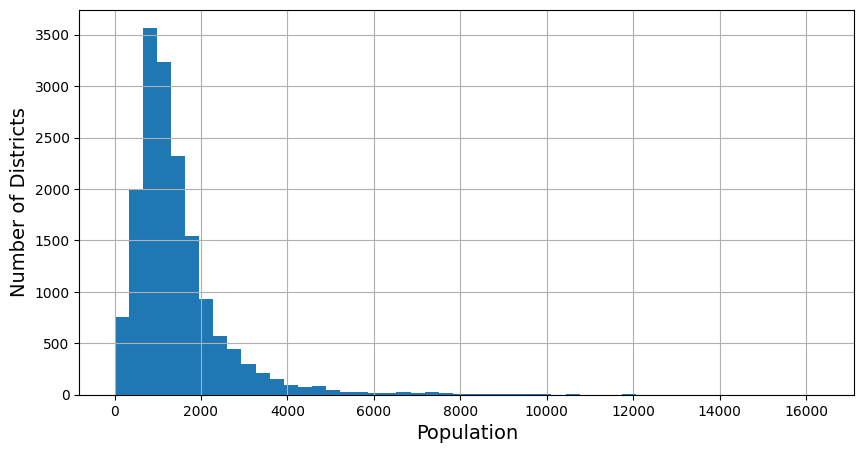

In [26]:
# Problem: Heavy tail distribution
strat_train_set_copy["population"].hist(bins=50, figsize=(10, 5))
plt.xlabel("Population")
plt.ylabel("Number of Districts")
plt.show()

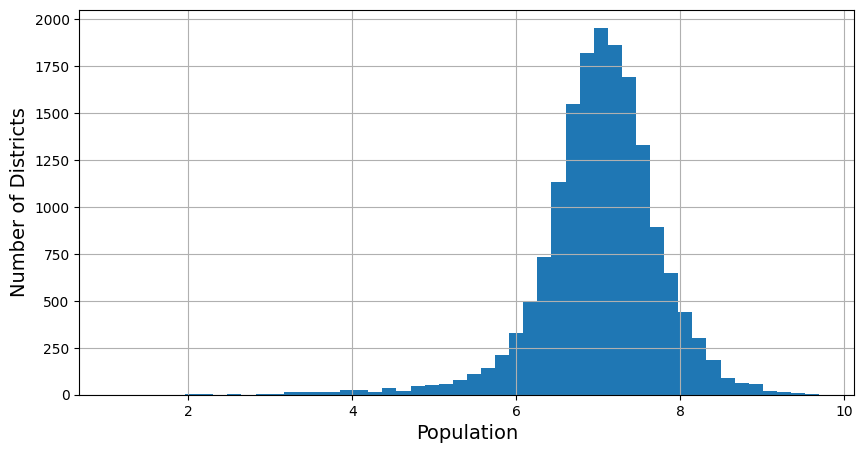

In [27]:
# Solution: We can applying a transformation such as log transformation to make it more symetrical
strat_train_set_copy["population"].apply(np.log).hist(bins=50, figsize=(10, 5))
plt.xlabel("Population")
plt.ylabel("Number of Districts")
plt.show()

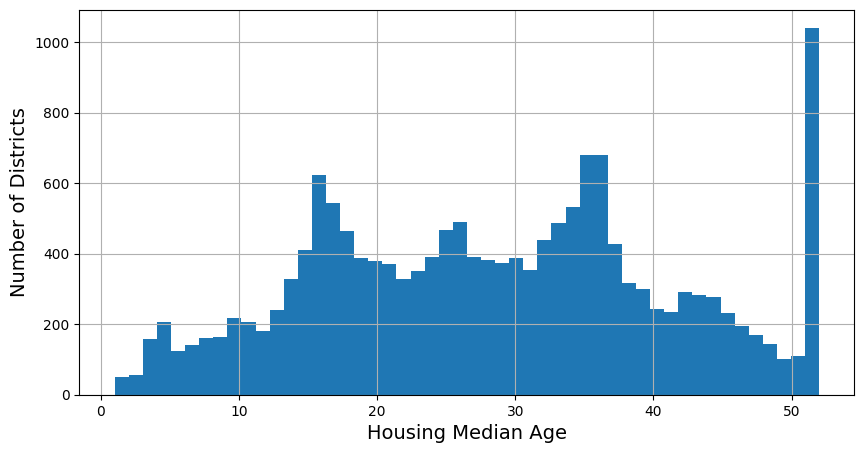

In [28]:
# Problem: Multimodal distribution (multiple peaks)
strat_train_set_copy["housing_median_age"].hist(bins=50, figsize=(10, 5))
plt.xlabel("Housing Median Age")
plt.ylabel("Number of Districts")
plt.show()

In [29]:
# Solution: We can use Gaussian RBF to meassure similarity to the peaks
from sklearn.metrics.pairwise import rbf_kernel

age_similar_to_35 = rbf_kernel(strat_train_set_copy[["housing_median_age"]], [[35]], gamma=0.1)
age_similar_to_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]])

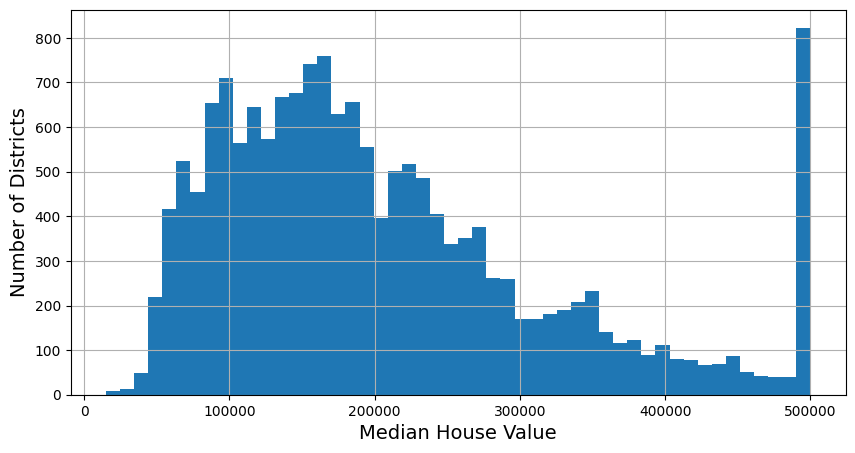

In [30]:
# Problem: The target attribute (median house value) also has a heavy tail distribution
strat_train_set_copy_labels.hist(bins=50, figsize=(10, 5))
plt.xlabel("Median House Value")
plt.ylabel("Number of Districts")
plt.show()

In [31]:
# Solution: We can use a TransformedTargetRegressor to apply a transformation to the target attribute
# How it works:
# 1. Applying a standardization transformation to the target attribute (median house value)
# 2. Train a linear regression model on the transformed target attribute
# 3. When making predictions, the result is scaled back to the original scale using the inverse transformation
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(strat_train_set_copy[["median_income"]], strat_train_set_copy_labels)

some_new_data = strat_train_set_copy[["median_income"]][:5]
model.predict(some_new_data)

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

### 3.4 - Handle population (FunctionTransformer)

In [32]:
# FunctionTransformer can be used to wrap any function into a transformer object, which can be used in a pipeline
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_population = log_transformer.fit_transform(strat_train_set_copy[["population"]])

log_population

,population
13096,7.362645
14973,6.501290
3785,6.331502
14689,7.520235
20507,7.555905
...,...
14207,6.843750
13105,7.257708
19301,7.942362
19121,7.452982


### 3.5 - Handle latitude and longtitude with CustomTransfermer (KMeans)

In [33]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin

# We use BaseEstimator so that we can use this class in a pipeline and for hyperparameter tuning
# We use TransformerMixin so that we can use the fit_transform() method in a pipeline
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=0.1, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, input_features=None):
        return [f"cluster_{i}" for i in range(self.n_clusters)]

In [34]:
# We can use the ClusterSimilarity to create new features that represent the similarity of each district to the cluster centers
# We use the sample_weight with the labels (median house value) to give more importance to the expensive districts
cluster_similarity = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)
similarities = cluster_similarity.fit_transform(strat_train_set_copy[["latitude", "longitude"]], sample_weight=strat_train_set_copy_labels)

# The result is a matrix of shape (n_samples, n_clusters)
# Each column represents the similarity of each district to one of the cluster centers, and each row represents a district
similarities[:5].round(2)

array([[0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.13, 0.55, 0.  , 0.56],
       [0.64, 0.  , 0.11, 0.04, 0.  , 0.  , 0.  , 0.  , 0.99, 0.  ],
       [0.  , 0.65, 0.  , 0.  , 0.01, 0.  , 0.49, 0.59, 0.  , 0.28],
       [0.63, 0.  , 0.  , 0.52, 0.  , 0.  , 0.  , 0.  , 0.2 , 0.  ],
       [0.87, 0.  , 0.03, 0.14, 0.  , 0.  , 0.  , 0.  , 0.89, 0.  ]])

## 4. Use Pipeline to Combine All

### Pipeline (A class to chain multiple data processing steps)
**Parameter:** A list of tuple (name, estimator)  
*Estimator must all be transformers, except for the last one (which can be anything like transformer, predictor, etc)
    
**Example:**
```
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

```
    
**Shortcut:** make_pipeline(estimator)  
With this function, we can just define estimator without specifying name

### ColumnTransformer (A class to apply preprocessing to different columns)
**Parameter:** A list of tuple (name, transformer, columns)  

**Example:**
```
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
"total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

```
    
**Shortcut:** make_column_transformer(transformer, columns)  
With this function, we can just create without specifying name

In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer

# We can use make_pipeline for shortcut to create a Pipeline
# A Pipeline allows us to chain multiple transformations together, so that we can apply them sequentially to the data
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# We can use make_column_transformer for shortcut to create a ColumnTransformer,
# A ColumnTransformer allows us to apply different transformations to different columns of the dataset
preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

In [36]:
# Combine all the transformations into a full pipeline
from sklearn.compose import ColumnTransformer

def column_ratio(X):
    return (X[:, 0] / X[:, 1]).reshape(-1, 1)

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_similarity = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

full_pipeline = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_similarity, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
], remainder=default_num_pipeline)

In [37]:
# Apply the full pipeline to the training data
housing_prepared = full_pipeline.fit_transform(strat_train_set_copy)
housing_prepared.shape

(16512, 24)

In [38]:
# Get the feature (column) names of the transformed dataset
full_pipeline.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__cluster_0', 'geo__cluster_1',
       'geo__cluster_2', 'geo__cluster_3', 'geo__cluster_4',
       'geo__cluster_5', 'geo__cluster_6', 'geo__cluster_7',
       'geo__cluster_8', 'geo__cluster_9',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN', 'remainder__housing_median_age'],
      dtype=object)

## Select and Train a Model

Step:
1. Use LinearRegression, DecisionTree, and Random Forest
2. Use Cross-Validation to get more accurate estimation

## Fine-Tune the Model

Step:
1. Use Randomized Search
2. Analyze the best model
3. Evaluate the model on the test set